# Reducers

# 🌟 What are reducers in LangGraph?
#### A reducer is a small function that tells LangGraph how to combine new state with old state.
##### Think of it like this:
    - A reducer decides how the graph should update its memory when a node returns new data.

## 🔧 What a reducer looks like
Here’s a simple reducer for messages:

python
```
def append_messages(old, new):
    return old + new
```


# Regular graph
- overwrites the value at each node if modified
Example: Create a chain graph

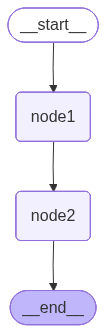

In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph , START , END

class simple_state(TypedDict):
    foo: int

# define nodes
#node 1
def node1(state):
    return {'foo': state['foo'] +1 }
def node2(state):
    return{'foo':state['foo'] +1}

# add nodes
builder = StateGraph(simple_state)

builder.add_node('node1' , node1)
builder.add_node('node2' , node2)
# add edges
builder.add_edge(START , 'node1')
builder.add_edge('node1', 'node2')
builder.add_edge('node2', END)

graph = builder.compile()
graph

In [2]:
graph.invoke({'foo': 1})

{'foo': 3}

### Note: state value is overwritten
### Branching
Create a branch with similar update but with branchng

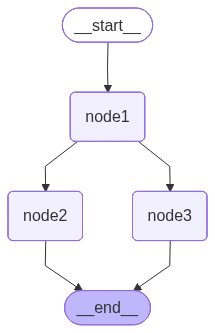

In [3]:
# define nodes
def node3(state):
    return {'foo': state['foo'] +2 }

# Build graph
builder = StateGraph(simple_state)
builder.add_node("node1", node1)
builder.add_node("node2", node2)
builder.add_node("node3", node3)

# Logic
builder.add_edge(START, "node1")
builder.add_edge("node1", "node2")
builder.add_edge("node1", "node3")
builder.add_edge("node2", END)
builder.add_edge("node3", END)

# Add
graph = builder.compile()
graph

In [4]:
from langgraph.errors import InvalidUpdateError
try:
    graph.invoke({'foo': 1})
except InvalidUpdateError as e:
    print(e)
    

At key 'foo': Can receive only one value per step. Use an Annotated key to handle multiple values.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_CONCURRENT_GRAPH_UPDATE


# Reducers
help update old data and new data like adding old and new data
- To apend data to a list instead of overwriting, use type Annotated to specify the reducer function
- operator.add helps add or apend the data
- When operator.add is applied to lists, it performs list concatenation.


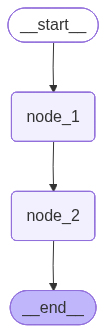

In [5]:
from typing import Annotated
from operator import add

class reducer_state(TypedDict):
    foo : Annotated[list[int],add]

#define nodes
def node_1(state:reducer_state):
    return {'foo' : [state['foo'][0] +1]}
def node_2(state:reducer_state):
    return {'foo' : [ foo +1 for foo in state['foo']]}

# Build graph
builder = StateGraph(reducer_state)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)

# Logic
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", END)

# Add
graph = builder.compile()

graph

In [6]:
graph.invoke({'foo':[1]})

{'foo': [1, 2, 2, 3]}

Now, our state key foo is a list.

This operator.add reducer function will append updates from each node to this list.
## test branching

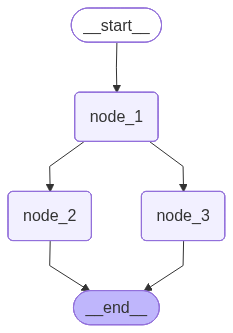

In [7]:
def node_2(state):
    return {'foo': [ state['foo'][-1] +1 ]} # update last value
def node_3(state):
    return {'foo': [ state['foo'][-1] +1 ]} # update last value

# Build graph
builder = StateGraph(reducer_state)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# Logic
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_1", "node_3")
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)

# Add
graph2 = builder.compile()

graph2

In [8]:
graph2.invoke({'foo':[2]})

{'foo': [2, 3, 4, 4]}

I/p - Node 1 - node 2 - node 3 -end

2 - 2+1 =3 - 3+1 = 4 - 3+1 =4 -end

input 'none' type

In [9]:
#from langgraph.error import TypeError
try:
    graph2.invoke({'foo':None})
except TypeError as e:
    print("TypeError: " , e)

TypeError:  can only concatenate list (not "NoneType") to list


## create a custom reducer

Example: Create a custom list adding two lists or handling 'None type'



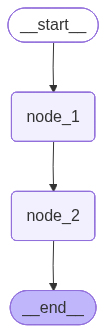

In [10]:
def add_list_reducer(left:list|None , right:list|None)-> list:
    """ add two lists perfectly while handling None type values

    args:
    left(list|None) : first list to join . Can be a None type
    right(list|None) : second list to join . Can be a None type

    Returns : 
        list: A new combined list . If input is None, its a empty list"""
    if not left:
        left = []
    if not right:
        right = []
    return left +right

# create a class with custom reducer function 'add_list_reducer'

class custom_reducer_state(TypedDict):
    foo: Annotated[list[int] , add_list_reducer]

# define nodes
def node_1(state):
    return {'foo': [state['foo'] + [1] ]}

def node_2(state):
    return {'foo': [1] }


# Build graph
builder = StateGraph(custom_reducer_state)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)

# Logic
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", END)

# Add
graph3 = builder.compile()

graph3 

In [11]:
graph3.invoke({'foo': [1]})

{'foo': [1, [1, 1], 1]}

values are still appended but with calculation

node 1 : add 1 to the list [1] = [1,2] that is, first value, first + 1 = second value

node 2 : append the list to original list. That is, [1,2] +[1] = [1,2,1]

In [12]:
graph3.invoke({'foo': None})

{'foo': [[1], 1]}

## Messages
add_messages reducer adds new message to old list

- MessagesState has a built-in messages key
- It also has a built-in add_messages reducer for this key
  
### Goal: 
    - Create reducer with add_messages
    - Use MessagesState inbuilt reducer 
    

In [13]:
from typing import Annotated
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages
from langgraph.graph import MessagesState

# define TypedDict state with add_messages reducer

class regular_reducer_state(TypedDict):
    messages : Annotated[list[AnyMessage] , add_messages]
    name: str
    age:int

# define with builtin Messagesstate

class built_in_MessagesState(MessagesState):
    name:str
    age:int
    

    

# How add_messages work?

add_messages(initial_messages , new_message)


In [21]:
from langgraph.graph.message import add_messages
from langchain_core.messages import AIMessage, HumanMessage

messages = [HumanMessage(Role="user" , content="HI, I would like to learn more about AI" , name= 'Diya'), 
           AIMessage(Role="Model" , content="Sure, AI is Artificial Intelligence that can be used to Human like tasks using human like reasoning" , name= 'GenAI')
           ]

New_message = [HumanMessage(Role="user" , content="OK. teach me Agentic AI" , name= 'Diya')]

add_messages(messages , New_message)


[HumanMessage(content='HI, I would like to learn more about AI', additional_kwargs={}, response_metadata={}, name='Diya', id='bf41a81b-c597-4c1d-806c-7f9725650ce3', Role='user'),
 AIMessage(content='Sure, AI is Artificial Intelligence that can be used to Human like tasks using human like reasoning', additional_kwargs={}, response_metadata={}, name='GenAI', id='8aa00305-77c1-4ca5-9dad-475d3b21cd60', tool_calls=[], invalid_tool_calls=[], Role='Model'),
 HumanMessage(content='OK. teach me Agentic AI', additional_kwargs={}, response_metadata={}, name='Diya', id='0ed203ab-b434-4ab0-b7df-8deb293b02c2', Role='user')]

# Using ID

#### IDing help identify the messages and replace it when needed

In [25]:
messages = [AIMessage(Role="Model" , content="what can i do for you?" , name= 'GenAI', id='1'),
            HumanMessage(Role="user" , content="HI, I would like to learn more about AI" , name= 'Diya', id= '2'), 
           ]

New_message = [HumanMessage(Role="user" , content="OK. teach me Agentic AI" , name= 'Diya', id='2')]

add_messages(messages , New_message)


[AIMessage(content='what can i do for you?', additional_kwargs={}, response_metadata={}, name='GenAI', id='1', tool_calls=[], invalid_tool_calls=[], Role='Model'),
 HumanMessage(content='OK. teach me Agentic AI', additional_kwargs={}, response_metadata={}, name='Diya', id='2', Role='user')]

In [37]:
# Initial state
initial_messages = [AIMessage(content="Hello! How can I assist you?", name="Model", id="1"),
                    HumanMessage(content="I'm looking for information on marine biology.", name="Lance", id="2")
                   ]

# New message to add
new_message = HumanMessage(content="I'm looking for information on whales, specifically", name="Lance", id="2")

# Test
new_messages = add_messages(initial_messages , new_message)
new_messages

[AIMessage(content='Hello! How can I assist you?', additional_kwargs={}, response_metadata={}, name='Model', id='1', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content="I'm looking for information on whales, specifically", additional_kwargs={}, response_metadata={}, name='Lance', id='2')]

# Remove Messages reducer 'RemoveMessage'

RemoveMessage is a reducer that removes a message from a list of messages stored in your graph state.

## Why it exists
LangGraph uses reducers to safely update state in a predictable way.

If your state contains a list of messages (like a chat history), you sometimes want to:

- add a messagesage
- remove a message
- replace a messagesage

In [39]:
from langchain_core.messages import RemoveMessage

new_messages.append(AIMessage(content="Interesting. I can show you some pics with details. select what you like" , name="Model" , id = "3"))
new_messages.append(HumanMessage(content="I picked 'black Orka', Teach me about him" , name= "Lance" , id = "4"))
new_messages

[AIMessage(content='Hello! How can I assist you?', additional_kwargs={}, response_metadata={}, name='Model', id='1', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content="I'm looking for information on whales, specifically", additional_kwargs={}, response_metadata={}, name='Lance', id='2'),
 AIMessage(content='Interesting. I can show you some pics with details. select what you like', additional_kwargs={}, response_metadata={}, name='Model', id='3', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content="I picked 'black Orka', Teach me about him", additional_kwargs={}, response_metadata={}, name='Lance', id='4'),
 AIMessage(content='Interesting. I can show you some pics with details. select what you like', additional_kwargs={}, response_metadata={}, name='Model', id='3', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content="I picked 'black Orka', Teach me about him", additional_kwargs={}, response_metadata={}, name='Lance', id='4')]

In [40]:
# print id
for m in new_messages:
    print(m.id)

1
2
3
4
3
4


In [41]:
# remove 3 and 4
deleted_messages = [RemoveMessage(id=m.id) for m in new_messages[-2:]]
deleted_messages
                    

[RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='3'),
 RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='4')]

In [42]:
new_messages

[AIMessage(content='Hello! How can I assist you?', additional_kwargs={}, response_metadata={}, name='Model', id='1', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content="I'm looking for information on whales, specifically", additional_kwargs={}, response_metadata={}, name='Lance', id='2'),
 AIMessage(content='Interesting. I can show you some pics with details. select what you like', additional_kwargs={}, response_metadata={}, name='Model', id='3', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content="I picked 'black Orka', Teach me about him", additional_kwargs={}, response_metadata={}, name='Lance', id='4'),
 AIMessage(content='Interesting. I can show you some pics with details. select what you like', additional_kwargs={}, response_metadata={}, name='Model', id='3', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content="I picked 'black Orka', Teach me about him", additional_kwargs={}, response_metadata={}, name='Lance', id='4')]

In [44]:
add_messages(new_messages , deleted_messages)

[AIMessage(content='Hello! How can I assist you?', additional_kwargs={}, response_metadata={}, name='Model', id='1', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content="I'm looking for information on whales, specifically", additional_kwargs={}, response_metadata={}, name='Lance', id='2')]